In [243]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)


REVIEW DATASET SAU KHI ĐÃ XỬ LÍ 

In [244]:
df = pd.read_csv('../data/processed/clean_ds_train_data.csv')
df_model = df.copy()

# Tạo nhãn khoảng
bins = [0, 3.0, 4.0, 5.0]
labels = [0, 1, 2]
label_names = ['Thấp (< 3.0)', 'Trung bình (3.0–4.0)', 'Tốt (≥ 4.0)']

rating_class = pd.cut(df_model['Aggregate rating'], bins=bins, labels=labels, include_lowest=True).astype(int)

print('Aggregate rating phân bố theo các khoảng:')
counts = rating_class.value_counts().sort_index()
for i, cnt in counts.items():
    print(f'  Khoảng {i} ({label_names[i]}): {cnt} mẫu ({cnt/len(rating_class)*100:.1f}%)')

Aggregate rating phân bố theo các khoảng:
  Khoảng 0 (Thấp (< 3.0)): 1901 mẫu (25.7%)
  Khoảng 1 (Trung bình (3.0–4.0)): 4388 mẫu (59.3%)
  Khoảng 2 (Tốt (≥ 4.0)): 1114 mẫu (15.0%)


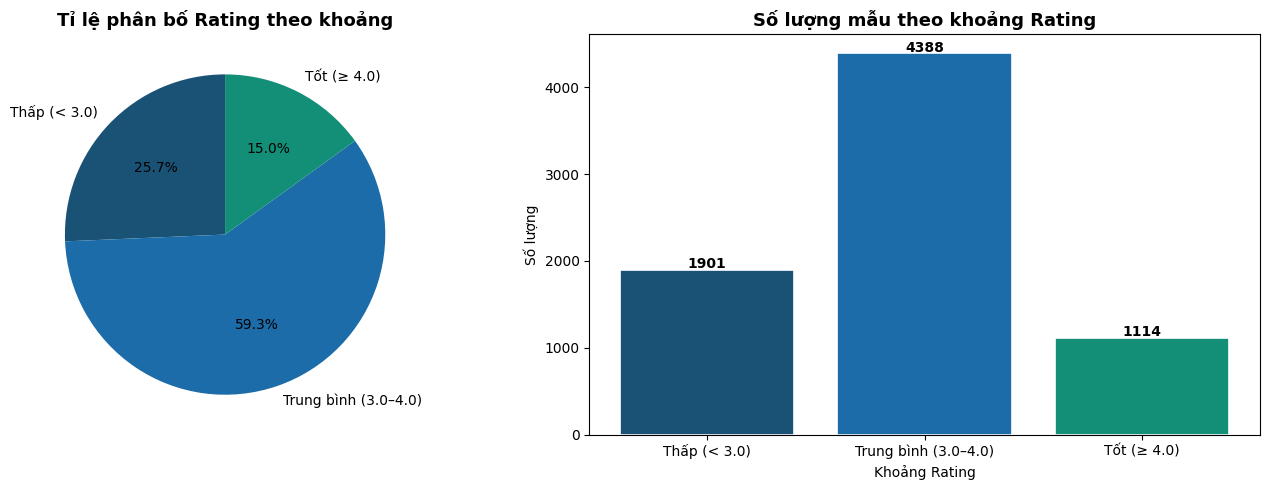

In [245]:
# Visualize 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#1a5276', '#1b6ca8', '#148f77']
counts_vals = [counts[i] for i in range(3)]  

axes[0].pie(counts_vals, labels=label_names, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[0].set_title('Tỉ lệ phân bố Rating theo khoảng', fontsize=13, fontweight='bold')

bars = axes[1].bar(label_names, counts_vals, color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, counts_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(val), ha='center', fontweight='bold')
axes[1].set_title('Số lượng mẫu theo khoảng Rating', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Khoảng Rating')
axes[1].set_ylabel('Số lượng')
plt.xticks(rotation=0) 

plt.tight_layout()
plt.show()

CHỌN ĐẶC TRƯNG CẦN DÙNG VÀ TÁCH DATATSET


In [246]:
target = 'Aggregate rating' 
features = [col for col in df_model.columns if col != target]

X = df_model[features]
y  = rating_class
print(f'Số features: {len(features)}')
print(f'Số samples: {len(X)}')

Số features: 10
Số samples: 7403


In [247]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)

print(f'Train set: {X_train.shape[0]} mẫu')
print(f'Valid set: {X_valid.shape[0]} mẫu')
print(f'\nTỷ lệ y_train(%):')
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

Train set: 5922 mẫu
Valid set: 1481 mẫu

Tỷ lệ y_train(%):
Aggregate rating
0    25.68
1    59.27
2    15.05
Name: proportion, dtype: float64


HUẤN LUYỆN MÔ HÌNH RANDOM FOREST CLASSIFIER

In [248]:
rf_model = RandomForestClassifier(
    n_estimators=200,        
    class_weight='balanced',   
    random_state=42               
)

# Huấn luyện
rf_model.fit(X_train, y_train)
print('Huấn luyện mô hình random forest classifier hoàn tất!')

Huấn luyện mô hình random forest classifier hoàn tất!


ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST CLASSIFIER

In [249]:
# Dự báo trên tập X_valid
y_pred = rf_model.predict(X_valid)

acc = accuracy_score(y_valid, y_pred)
f1_macro = f1_score(y_valid, y_pred, average='macro')
f1_weighted = f1_score(y_valid, y_pred, average='weighted')


print(f'Accuracy       : {acc:.4f} ({acc*100:.2f}%)')
print(f'F1 (macro)     : {f1_macro:.4f}')
print(f'F1 (weighted)  : {f1_weighted:.4f}')

print()
print('Classification Report:')
print(classification_report(
    y_valid, 
    y_pred, 
    target_names=['Thấp', 'Trung bình', 'Tốt'] 
))

Accuracy       : 0.7218 (72.18%)
F1 (macro)     : 0.6714
F1 (weighted)  : 0.7119

Classification Report:
              precision    recall  f1-score   support

        Thấp       0.68      0.50      0.58       380
  Trung bình       0.73      0.86      0.79       878
         Tốt       0.77      0.57      0.65       223

    accuracy                           0.72      1481
   macro avg       0.72      0.64      0.67      1481
weighted avg       0.72      0.72      0.71      1481



In [250]:
# Đánh giá theo Cross-validation 5-fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)

print(f'\nCross-Validation (5-fold) F1 macro:')
print(f'Scores: {[round(s, 4) for s in cv_scores]}')
print(f'Mean  : {cv_scores.mean():.4f}')
print(f'Std   : {cv_scores.std():.4f}')


Cross-Validation (5-fold) F1 macro:
Scores: [np.float64(0.6487), np.float64(0.6685), np.float64(0.655), np.float64(0.643), np.float64(0.6547)]
Mean  : 0.6540
Std   : 0.0085


CONFUSION MATRIX RANDOM FOREST CLASSIFIER

In [251]:
cm = confusion_matrix(y_valid, y_pred)

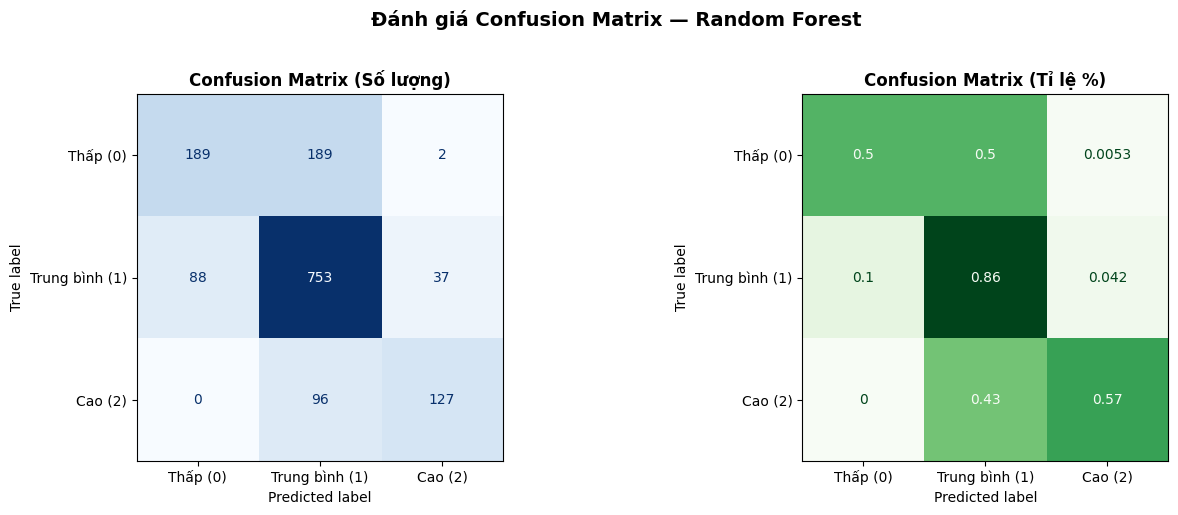

In [252]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Ma trận số lượng
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=['Thấp (0)', 'Trung bình (1)', 'Cao (2)'])
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Số lượng)', fontweight='bold')

# Ma trận tỉ lệ %
cm_norm = confusion_matrix(y_valid, y_pred, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                display_labels=['Thấp (0)', 'Trung bình (1)', 'Cao (2)'])
disp2.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix (Tỉ lệ %)', fontweight='bold')

plt.suptitle('Đánh giá Confusion Matrix — Random Forest', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

FEATURE IMPORTANCE

In [253]:
importances = rf_model.feature_importances_
feature_names = X.columns
feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})


feat_df = feat_df.sort_values(by='Importance', ascending=False)

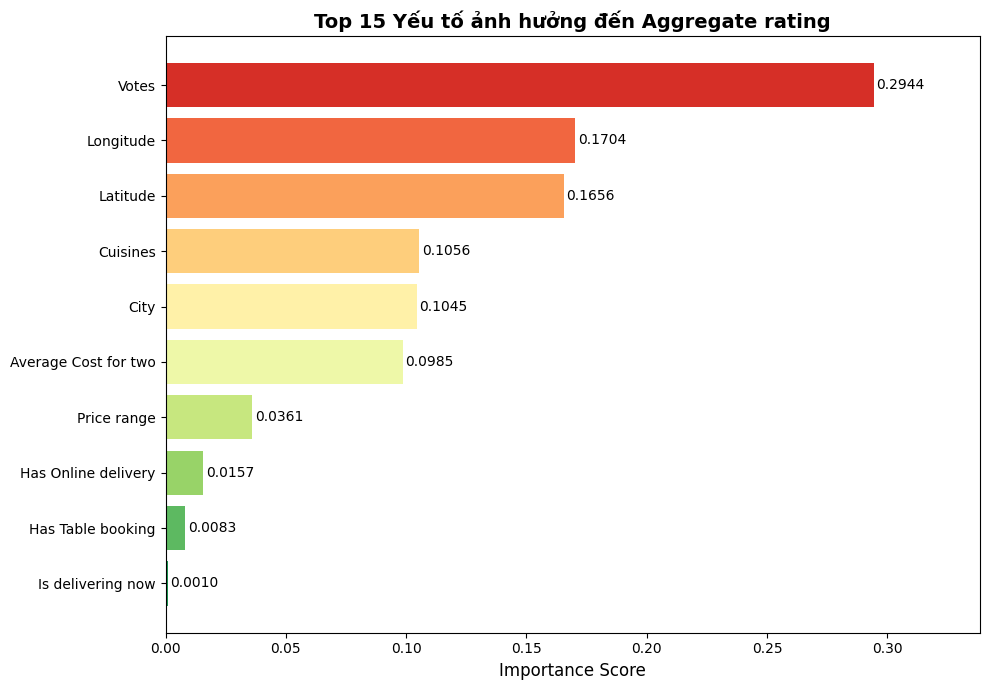

Yếu tố quan trọng nhất là "Votes" (score = 0.2944)


In [254]:
# Visualize
top15 = feat_df.head(15)

fig, ax = plt.subplots(figsize=(10, 7))

colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(top15)))
bars = ax.barh(top15['Feature'][::-1], top15['Importance'][::-1], color=colors)

for bar, val in zip(bars, top15['Importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)

ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Top 15 Yếu tố ảnh hưởng đến Aggregate rating', fontsize=14, fontweight='bold')
ax.set_xlim(0, top15['Importance'].max() * 1.15)
plt.tight_layout()
plt.show()

print(f'Yếu tố quan trọng nhất là "{feat_df.iloc[0]["Feature"]}" '
      f'(score = {feat_df.iloc[0]["Importance"]:.4f})')